# Historical CVaR Portfolio Optimization

This notebook implements and evaluates historical CVaR optimization for a 10-stock portfolio. It is designed for a poster-ready workflow: 
1. clean data processing, 
2. explicit optimization formulation, 
3. out-of-sample backtesting, 
4. rolling monthly re-optimization, 
5. mean-CVaR, 
6. efficient frontier diagnostics, and 
7. professional figures.

## Import & Setup

In [1]:
# Uncomment in Colab if needed.
# %pip -q install yfinance scipy

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import sparse
from scipy.optimize import linprog

try:
    import yfinance as yf
except ImportError:
    yf = None

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": False,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Configuration

Replace `TICKERS` with your exact 10 stocks before producing final poster results. The default list is only a diversified example.

In [2]:
TICKERS = ["NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "AVGO", "META", "TSLA", "WMT", "AMD"]

# For reproducible poster results, set fixed dates instead of leaving END_DATE as None.
START_DATE = "2013-01-01"
END_DATE = None

# Set LOCAL_PRICE_FILE to a CSV with a Date column and ticker columns if you already have prices.
LOCAL_PRICE_FILE = None
DATE_COLUMN = "Date"

TRAIN_YEARS = 10
TEST_YEARS = 3
USE_MOST_RECENT_WINDOW = True

CONFIDENCE_LEVEL = 0.95
TRADING_DAYS = 252
REBALANCE_FREQ = "M"

# Long-only portfolio by default. Set MAX_WEIGHT below 1.0 if you want diversification caps.
MIN_WEIGHT = 0.0
MAX_WEIGHT = 1.0

# Annual risk-free rate used only for Sharpe ratio. Keep 0.0 if you want excess return vs cash ignored.
RISK_FREE_RATE = 0.0

# Optional transaction cost for monthly rebalancing. 0 keeps the comparison clean.
TRANSACTION_COST_BPS = 0.0

EXPORT_FIGURES = True
FIGURE_DIR = Path("figures")

if len(TICKERS) != 10:
    raise ValueError("This project expects exactly 10 tickers.")

## Data Loading & Processing

In [3]:
def load_prices(tickers, start_date, end_date=None, local_price_file=None, date_column="Date"):
    """Load adjusted close prices from a local CSV or Yahoo Finance."""
    if local_price_file is not None:
        raw = pd.read_csv(local_price_file)
        if date_column not in raw.columns:
            raise ValueError(f"Local price file must contain a '{date_column}' column.")
        raw[date_column] = pd.to_datetime(raw[date_column])
        prices = raw.set_index(date_column)
        missing = [ticker for ticker in tickers if ticker not in prices.columns]
        if missing:
            raise ValueError(f"Missing ticker columns in local CSV: {missing}")
        prices = prices[tickers]
    else:
        if yf is None:
            raise ImportError("Install yfinance or provide LOCAL_PRICE_FILE.")
        data = yf.download(
            tickers,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
            group_by="column",
        )
        if isinstance(data.columns, pd.MultiIndex):
            if "Close" in data.columns.get_level_values(0):
                prices = data["Close"]
            elif "Adj Close" in data.columns.get_level_values(0):
                prices = data["Adj Close"]
            else:
                raise ValueError("Could not find Close or Adj Close prices in downloaded data.")
        else:
            prices = data[["Close"]].rename(columns={"Close": tickers[0]})
        prices = prices.reindex(columns=tickers)

    prices = prices.sort_index()
    prices = prices[~prices.index.duplicated(keep="last")]
    prices = prices.dropna(how="all").ffill().dropna()
    prices = prices.astype(float)

    if prices.empty:
        raise ValueError("Price data is empty after cleaning.")

    return prices


def compute_returns(prices):
    returns = prices.pct_change().dropna(how="any")
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    if returns.empty:
        raise ValueError("Return data is empty after cleaning.")
    return returns

In [4]:
# Compute prices and returns, and display coverage info.
prices = load_prices(TICKERS, START_DATE, END_DATE, LOCAL_PRICE_FILE, DATE_COLUMN)
returns = compute_returns(prices)

coverage = pd.DataFrame({
    "first_price": prices.apply(lambda s: s.first_valid_index()),
    "last_price": prices.apply(lambda s: s.last_valid_index()),
    "missing_data": prices.isna().sum(),
})

print(f"Price observations: {len(prices):,}")
print(f"Return observations: {len(returns):,}")
print(f"Full return sample: {returns.index.min().date()} to {returns.index.max().date()}")
display(coverage)

Price observations: 3,363
Return observations: 3,362
Full return sample: 2013-01-03 to 2026-05-15


,first_price,last_price,missing_data
Ticker,,,
NVDA,2013-01-02,2026-05-15,0
AAPL,2013-01-02,2026-05-15,0
MSFT,2013-01-02,2026-05-15,0
AMZN,2013-01-02,2026-05-15,0
GOOGL,2013-01-02,2026-05-15,0
AVGO,2013-01-02,2026-05-15,0
META,2013-01-02,2026-05-15,0
TSLA,2013-01-02,2026-05-15,0
WMT,2013-01-02,2026-05-15,0


## Exploratory Data Analysis

In [9]:
if EXPORT_FIGURES:
    FIGURE_DIR.mkdir(exist_ok=True)


def export_eda_figure(fig, filename):
    if EXPORT_FIGURES:
        fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")


var_threshold = returns.quantile(1.0 - CONFIDENCE_LEVEL)
eda_summary = pd.DataFrame({
    "annualized_mean_return": (1.0 + returns.mean()) ** TRADING_DAYS - 1.0,
    "annualized_volatility": returns.std(ddof=1) * np.sqrt(TRADING_DAYS),
    "skewness": returns.skew(),
    "excess_kurtosis": returns.kurtosis(),
    f"daily_var_{int(CONFIDENCE_LEVEL * 100)}_loss": -var_threshold,
    f"daily_cvar_{int(CONFIDENCE_LEVEL * 100)}_loss": returns.apply(
        lambda s: -s[s <= s.quantile(1.0 - CONFIDENCE_LEVEL)].mean()
    ),
    "worst_daily_return": returns.min(),
    "best_daily_return": returns.max(),
})

display(
    eda_summary.style.format({
        "annualized_mean_return": "{:.2%}",
        "annualized_volatility": "{:.2%}",
        f"daily_var_{int(CONFIDENCE_LEVEL * 100)}_loss": "{:.2%}",
        f"daily_cvar_{int(CONFIDENCE_LEVEL * 100)}_loss": "{:.2%}",
        "worst_daily_return": "{:.2%}",
        "best_daily_return": "{:.2%}",
        "skewness": "{:.2f}",
        "excess_kurtosis": "{:.2f}",
    })
)

,annualized_mean_return,annualized_volatility,skewness,excess_kurtosis,daily_var_95_loss,daily_cvar_95_loss,worst_daily_return,best_daily_return
Ticker,,,,,,,,
NVDA,82.27%,45.50%,0.60,9.29,4.13%,6.19%,-18.76%,29.81%
AAPL,29.29%,28.22%,0.02,6.90,2.66%,4.05%,-12.86%,15.33%
MSFT,29.11%,26.39%,0.01,8.26,2.50%,3.77%,-14.74%,14.22%
AMZN,32.15%,32.40%,0.26,6.19,3.01%,4.60%,-14.05%,14.13%
GOOGL,31.11%,27.94%,0.43,7.32,2.54%,3.89%,-11.63%,16.26%
AVGO,58.59%,38.05%,0.38,10.24,3.35%,5.04%,-19.91%,24.43%
META,35.65%,38.21%,0.41,22.78,3.31%,5.21%,-26.39%,29.61%
TSLA,73.78%,57.51%,0.41,4.88,5.15%,7.78%,-21.06%,24.40%
WMT,18.67%,20.55%,0.24,14.64,1.75%,2.85%,-11.38%,11.71%


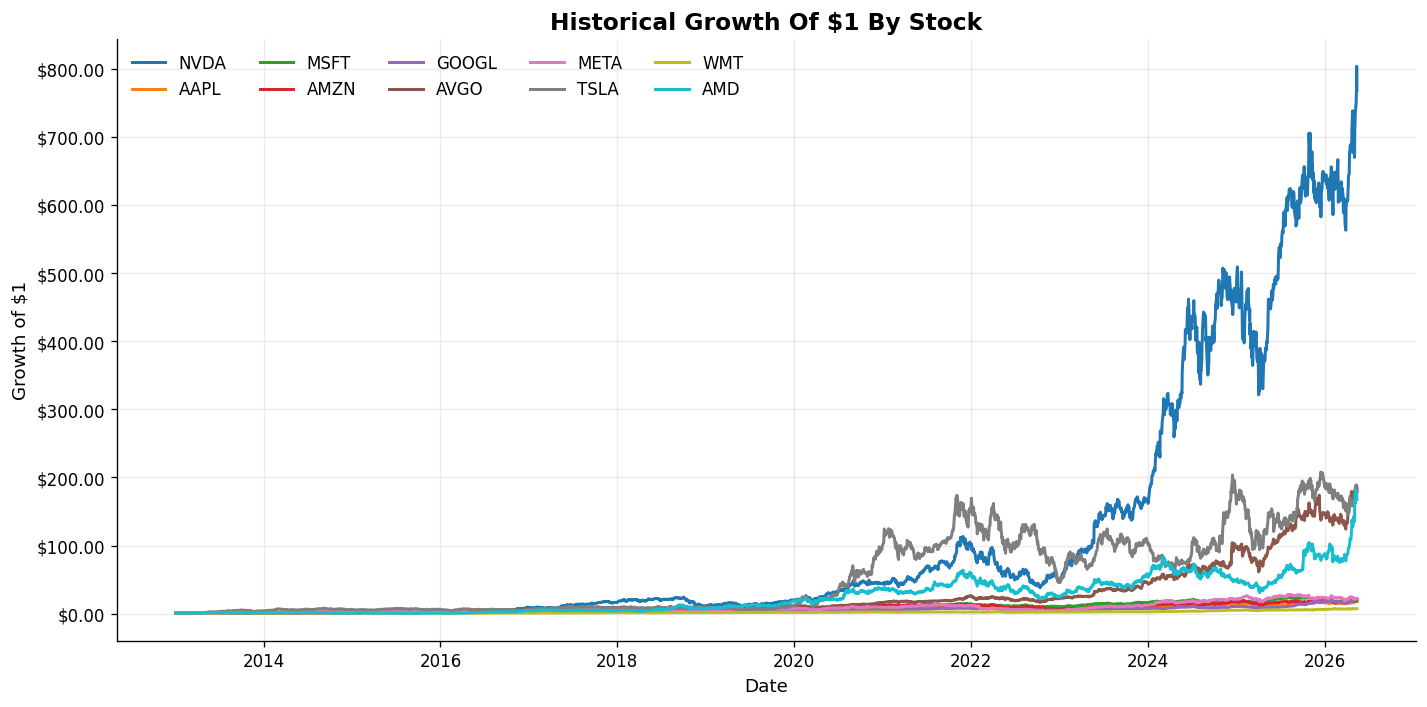

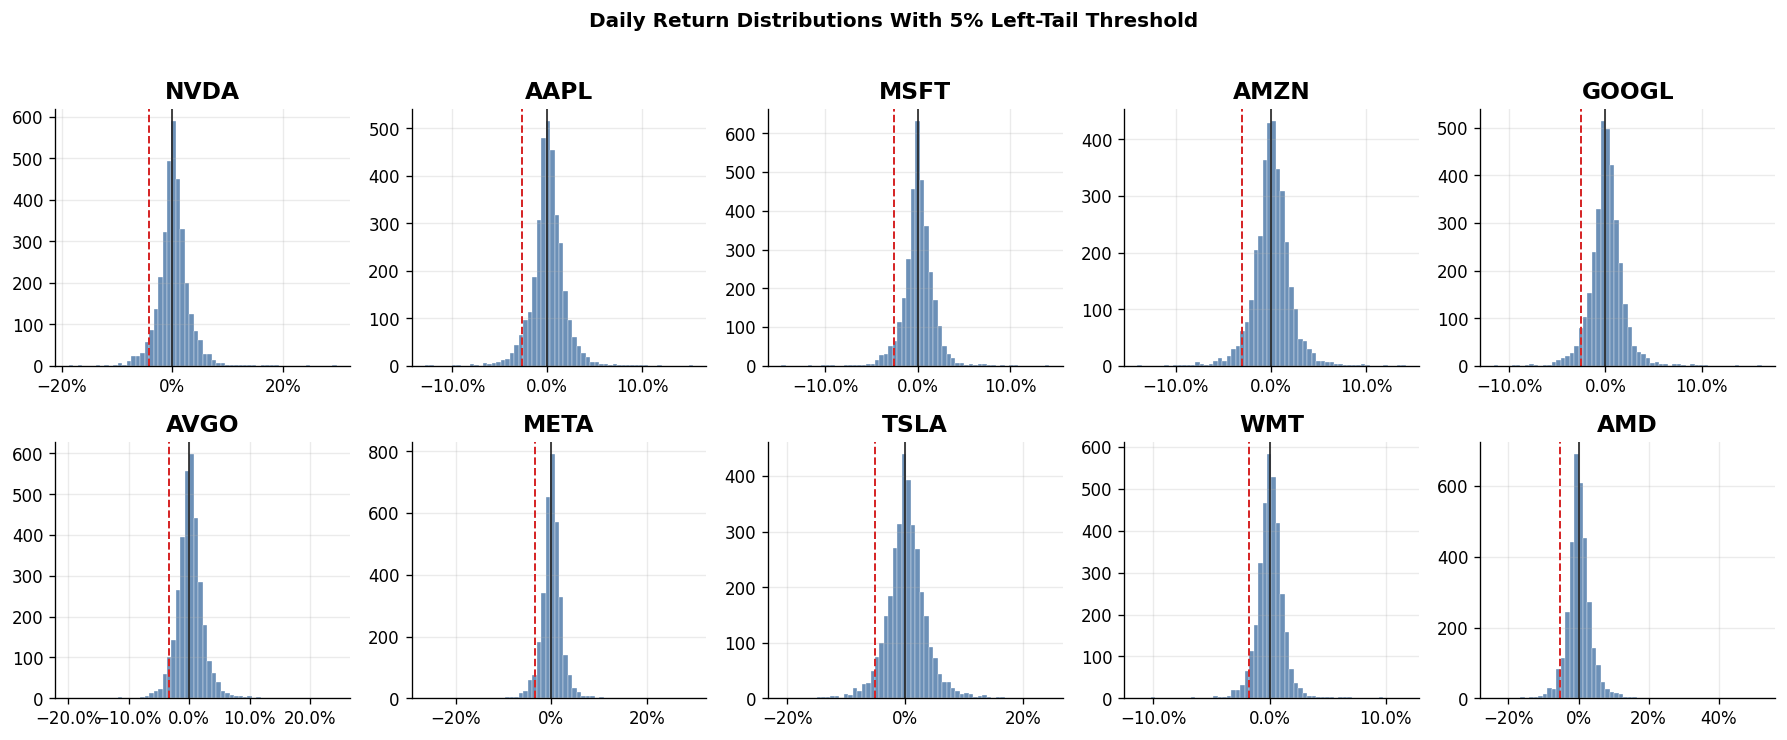

In [10]:
# Calculate cumulative growth of $1 invested in each stock over time, and plot the growth curves. 
# This visualization helps to understand the long-term performance of each stock and how they compare to each other.
stock_growth = (1.0 + returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for ticker in returns.columns:
    ax.plot(stock_growth.index, stock_growth[ticker], linewidth=1.8, label=ticker)
ax.set_title("Historical Growth Of $1 By Stock")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
ax.legend(ncol=5, loc="upper left")
fig.tight_layout()
export_eda_figure(fig, "eda_stock_growth.png")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=False, sharey=False)
axes = np.asarray(axes).ravel()
for ax, ticker in zip(axes, returns.columns):
    series = returns[ticker].dropna()
    q05 = series.quantile(1.0 - CONFIDENCE_LEVEL)
    ax.hist(series, bins=60, color="#4c78a8", alpha=0.82, edgecolor="white", linewidth=0.25)
    ax.axvline(0.0, color="#222222", linewidth=1.0)
    ax.axvline(q05, color="#d62728", linestyle="--", linewidth=1.2)
    ax.set_title(ticker)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
fig.suptitle("Daily Return Distributions With 5% Left-Tail Threshold", fontweight="bold", y=1.02)
fig.tight_layout()
export_eda_figure(fig, "eda_return_distributions.png")
plt.show()

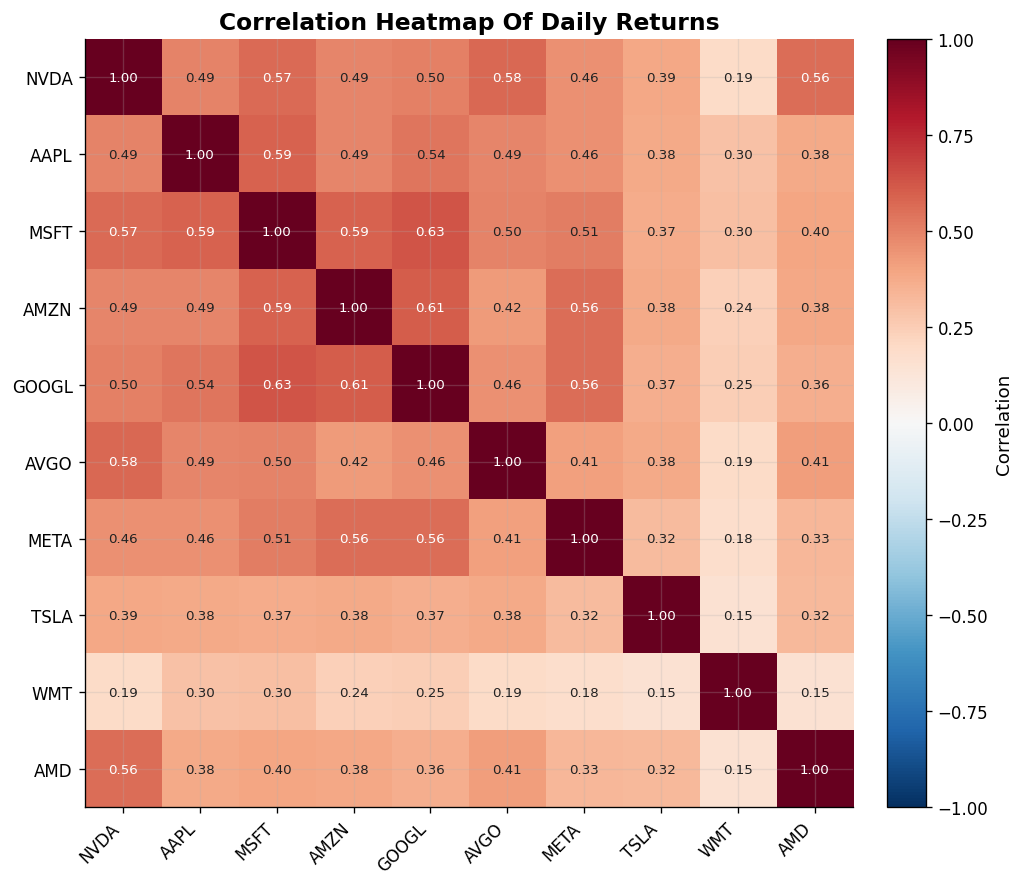

In [11]:
# Correlation heatmap with values annotated and colored for visibility. 
# This can help identify pairs of stocks that move together or in opposite directions, which is important for diversification and risk management in portfolio optimization.
correlation = returns.corr()

fig, ax = plt.subplots(figsize=(8.5, 7.5))
image = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap Of Daily Returns")
ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))
ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation.index)

for i in range(len(correlation.index)):
    for j in range(len(correlation.columns)):
        value = correlation.iloc[i, j]
        text_color = "white" if abs(value) >= 0.55 else "#222222"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Correlation")
fig.tight_layout()
export_eda_figure(fig, "eda_correlation_heatmap.png")
plt.show()

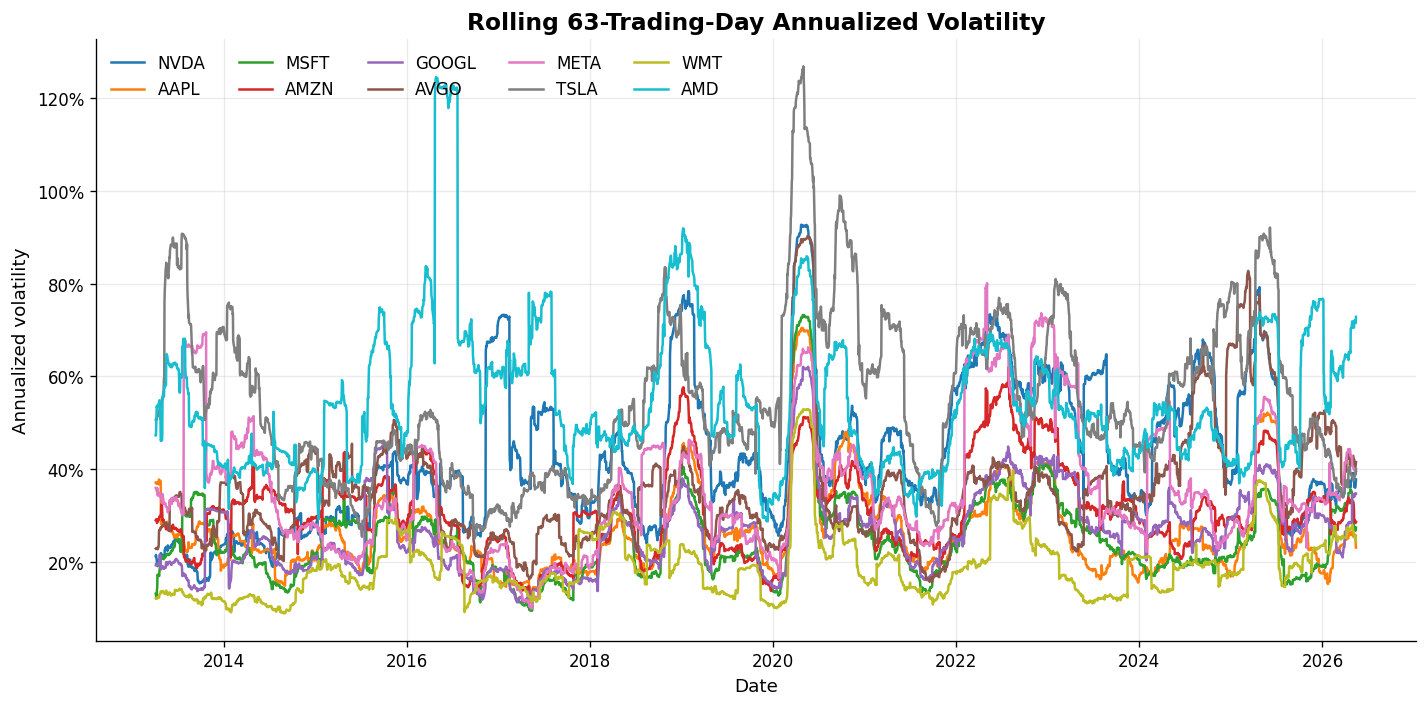

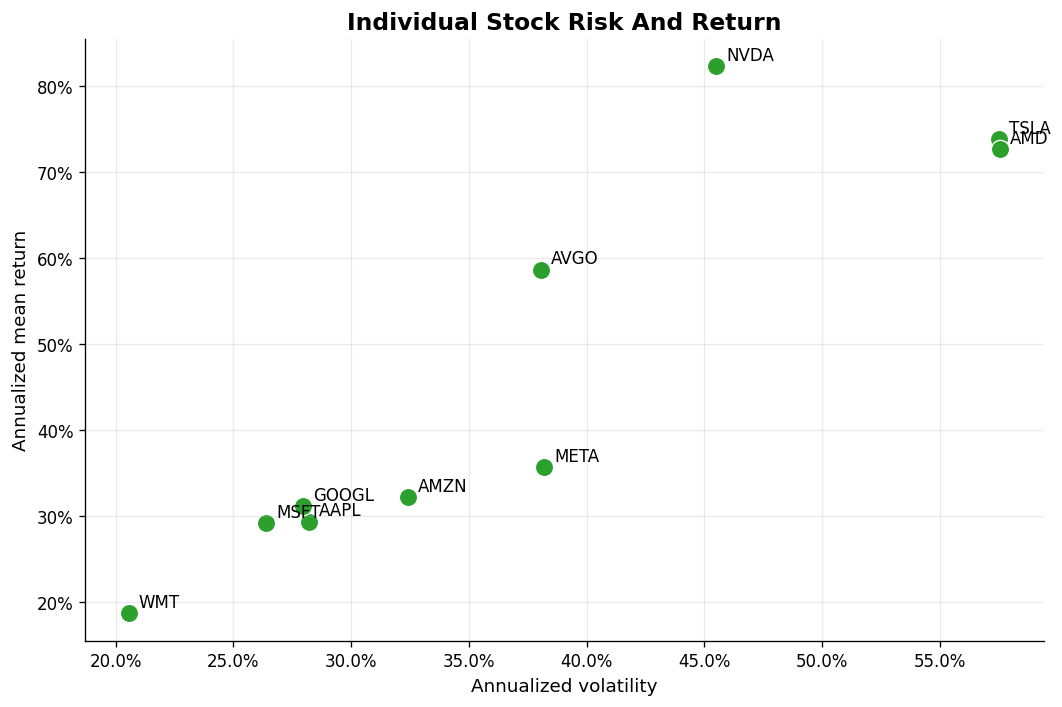

In [12]:
rolling_window = 63
rolling_volatility = returns.rolling(rolling_window).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(12, 6))
for ticker in returns.columns:
    ax.plot(rolling_volatility.index, rolling_volatility[ticker], linewidth=1.5, label=ticker)
ax.set_title(f"Rolling {rolling_window}-Trading-Day Annualized Volatility")
ax.set_ylabel("Annualized volatility")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(ncol=5, loc="upper left")
fig.tight_layout()
export_eda_figure(fig, "eda_rolling_volatility.png")
plt.show()

asset_annual_return = (1.0 + returns.mean()) ** TRADING_DAYS - 1.0
asset_annual_volatility = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(asset_annual_volatility, asset_annual_return, s=120, color="#2ca02c", edgecolor="white", linewidth=0.8)
for ticker in returns.columns:
    ax.annotate(ticker, (asset_annual_volatility[ticker], asset_annual_return[ticker]), xytext=(6, 4), textcoords="offset points")
ax.set_title("Individual Stock Risk And Return")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized mean return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
fig.tight_layout()
export_eda_figure(fig, "eda_asset_risk_return.png")
plt.show()

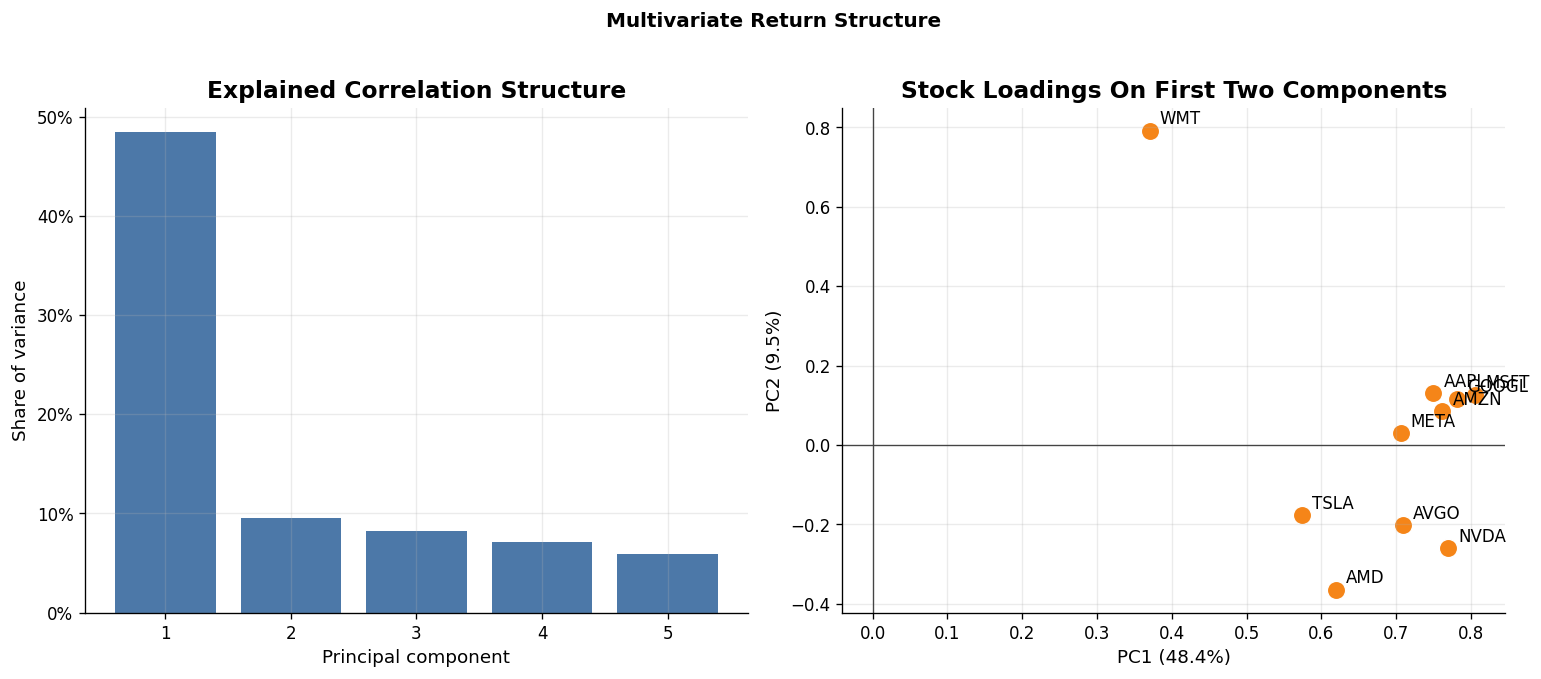

,PC1,PC2
Ticker,,
NVDA,0.770,-0.259
AAPL,0.750,0.130
MSFT,0.806,0.127
AMZN,0.762,0.085
GOOGL,0.781,0.117
AVGO,0.709,-0.202
META,0.706,0.030
TSLA,0.573,-0.177
WMT,0.371,0.791


In [13]:
# Principal-component view of the multivariate correlation structure.
standardized_returns = (returns - returns.mean()) / returns.std(ddof=0)
corr_matrix = standardized_returns.corr().to_numpy()
eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
explained_variance = eigenvalues / eigenvalues.sum()

loadings = pd.DataFrame(
    eigenvectors[:, :2] * np.sqrt(eigenvalues[:2]),
    index=returns.columns,
    columns=["PC1", "PC2"],
)

n_components_to_plot = min(5, len(explained_variance))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].bar(
    range(1, n_components_to_plot + 1),
    explained_variance[:n_components_to_plot],
    color="#4c78a8",
)
axes[0].set_xticks(range(1, n_components_to_plot + 1))
axes[0].set_title("Explained Correlation Structure")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Share of variance")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[1].scatter(loadings["PC1"], loadings["PC2"], s=120, color="#f58518", edgecolor="white", linewidth=0.8)
for ticker, row in loadings.iterrows():
    axes[1].annotate(ticker, (row["PC1"], row["PC2"]), xytext=(6, 4), textcoords="offset points")
axes[1].axhline(0, color="#444444", linewidth=0.8)
axes[1].axvline(0, color="#444444", linewidth=0.8)
axes[1].set_title("Stock Loadings On First Two Components")
axes[1].set_xlabel(f"PC1 ({explained_variance[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({explained_variance[1]:.1%})")

fig.suptitle("Multivariate Return Structure", fontweight="bold", y=1.02)
fig.tight_layout()
export_eda_figure(fig, "eda_multivariate_pca.png")
plt.show()

display(loadings.style.format("{:.3f}"))

## Chronological Train/Test Split

- The first 10 years are used to estimate portfolio weights. 
- The following 3 years are used only for evaluation (or called out-of-sample)
- For rolling monthly strategies, each month is optimized using the trailing 10 years available before that month begins.

In [14]:
def make_train_test_split(returns, train_years=10, test_years=3, use_most_recent_window=True):
    required_years = train_years + test_years
    sample = returns.copy()

    if use_most_recent_window:
        analysis_start = sample.index.max() - pd.DateOffset(years=required_years)
        sample = sample.loc[sample.index >= analysis_start]

    start = sample.index.min()
    train_end = start + pd.DateOffset(years=train_years)
    test_end = train_end + pd.DateOffset(years=test_years)

    train = sample.loc[sample.index < train_end]
    test = sample.loc[(sample.index >= train_end) & (sample.index < test_end)]

    if len(train) < TRADING_DAYS * (train_years - 1):
        raise ValueError("Training window is too short. Check START_DATE and price coverage.")
    if len(test) < TRADING_DAYS * (test_years - 1):
        raise ValueError("Test window is too short. Check END_DATE and price coverage.")

    return sample, train, test


sample_returns, train_returns, test_returns = make_train_test_split(
    returns,
    train_years=TRAIN_YEARS,
    test_years=TEST_YEARS,
    use_most_recent_window=USE_MOST_RECENT_WINDOW,
)

split_summary = pd.DataFrame({
    "period": ["Training", "Out-of-sample test"],
    "start": [train_returns.index.min().date(), test_returns.index.min().date()],
    "end": [train_returns.index.max().date(), test_returns.index.max().date()],
    "trading_days": [len(train_returns), len(test_returns)],
})

display(split_summary)

,period,start,end,trading_days
0,Training,2013-05-15,2023-05-12,2517
1,Out-of-sample test,2023-05-15,2026-05-14,753


In [22]:
# Show one historical scenario: returns of all stocks on one training day
scenario_id = 0
scenario_date = train_returns.index[scenario_id]

scenario_table = train_returns.iloc[scenario_id].to_frame(name="daily_return")
scenario_table["daily_return_pct"] = scenario_table["daily_return"] * 100

print("Scenario date:", scenario_date.date())
display(scenario_table)

Scenario date: 2013-05-15


,daily_return,daily_return_pct
Ticker,,
NVDA,0.0173,1.7301
AAPL,-0.0338,-3.3817
MSFT,0.0095,0.9544
AMZN,-0.0066,-0.6596
GOOGL,0.0325,3.2454
AVGO,0.0142,1.4243
META,-0.0174,-1.7362
TSLA,0.0192,1.9222
WMT,0.0137,1.3709


In [23]:
# Example: compute portfolio return/loss for one day using equal weights
example_weights = pd.Series(1 / len(TICKERS), index=TICKERS)

example_return = float(train_returns.iloc[scenario_id] @ example_weights)
example_loss = -example_return

print("Scenario date:", scenario_date.date())
print("Portfolio return:", f"{example_return:.4%}")
print("Portfolio loss:", f"{example_loss:.4%}")

Scenario date: 2013-05-15
Portfolio return: 0.7687%
Portfolio loss: -0.7687%


## Optimization and Backtest Functions

Static portfolios below are treated as true buy-and-hold portfolios: 
- Weights are set at the start of the out-of-sample period and then allowed to drift. 
- Rolling strategies rebalance once per month.

In [15]:
def solve_cvar_lp(returns, alpha=0.95, target_daily_return=None, weight_bounds=(0.0, 1.0)):
    """Solve a long-only historical CVaR linear program."""
    scenario_returns = returns.to_numpy(dtype=float)
    t_count, n_assets = scenario_returns.shape

    if t_count == 0:
        raise ValueError("No return scenarios were supplied.")

    n_variables = n_assets + 1 + t_count
    eta_index = n_assets
    u_start = n_assets + 1

    c = np.zeros(n_variables)
    c[eta_index] = 1.0
    c[u_start:] = 1.0 / ((1.0 - alpha) * t_count)

    # -R_t w - eta - u_t <= 0 is equivalent to u_t >= loss_t(w) - eta.
    a_left = sparse.csr_matrix(-scenario_returns)
    a_eta = sparse.csr_matrix(-np.ones((t_count, 1)))
    a_u = -sparse.eye(t_count, format="csr")
    a_ub = sparse.hstack([a_left, a_eta, a_u], format="csr")
    b_ub = np.zeros(t_count)

    if target_daily_return is not None:
        mu = returns.mean().to_numpy(dtype=float)
        target_row_dense = np.zeros((1, n_variables))
        target_row_dense[0, :n_assets] = -mu
        target_row = sparse.csr_matrix(target_row_dense)
        a_ub = sparse.vstack([a_ub, target_row], format="csr")
        b_ub = np.concatenate([b_ub, [-target_daily_return]])

    a_eq_dense = np.zeros((1, n_variables))
    a_eq_dense[0, :n_assets] = 1.0
    a_eq = sparse.csr_matrix(a_eq_dense)
    b_eq = np.array([1.0])

    bounds = [weight_bounds] * n_assets + [(None, None)] + [(0.0, None)] * t_count

    result = linprog(
        c,
        A_ub=a_ub,
        b_ub=b_ub,
        A_eq=a_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )

    if not result.success:
        raise RuntimeError(f"CVaR optimization failed: {result.message}")

    weights = pd.Series(result.x[:n_assets], index=returns.columns, name="weight")
    weights[np.abs(weights) < 1e-8] = 0.0
    weights = weights / weights.sum()

    eta = float(result.x[eta_index])
    objective_cvar = float(result.fun)

    return weights, {"eta_var_loss": eta, "objective_cvar_loss": objective_cvar}


def buy_and_hold_returns(asset_returns, initial_weights):
    """Return portfolio returns from initial weights without daily rebalancing."""
    weights = pd.Series(initial_weights, index=asset_returns.columns, dtype=float)
    asset_growth = (1.0 + asset_returns).cumprod()
    wealth = asset_growth.mul(weights, axis=1).sum(axis=1)
    portfolio_returns = wealth.pct_change()
    portfolio_returns.iloc[0] = wealth.iloc[0] - 1.0
    return portfolio_returns.rename("portfolio_return")


def equal_weight_target_return(window_returns):
    equal_weights = pd.Series(1.0 / window_returns.shape[1], index=window_returns.columns)
    return float((window_returns @ equal_weights).mean())


def rolling_monthly_strategy(
    all_returns,
    test_index,
    optimizer,
    train_years=10,
    transaction_cost_bps=0.0,
):
    """Optimize at the start of each test month using the trailing training window."""
    test_returns_local = all_returns.loc[test_index]
    monthly_periods = test_returns_local.index.to_period(REBALANCE_FREQ).unique()

    strategy_returns = []
    weights_by_month = []
    previous_weights = None

    for period in monthly_periods:
        month_returns = test_returns_local.loc[test_returns_local.index.to_period(REBALANCE_FREQ) == period]
        rebalance_date = month_returns.index.min()
        train_start = rebalance_date - pd.DateOffset(years=train_years)
        historical_window = all_returns.loc[(all_returns.index >= train_start) & (all_returns.index < rebalance_date)]

        if len(historical_window) < TRADING_DAYS * (train_years - 1):
            raise ValueError(f"Not enough historical data before {rebalance_date.date()} for rolling optimization.")

        weights = optimizer(historical_window)
        period_returns = buy_and_hold_returns(month_returns, weights)

        if previous_weights is not None and transaction_cost_bps > 0:
            turnover = float(np.abs(weights - previous_weights).sum())
            cost = turnover * transaction_cost_bps / 10_000.0
            period_returns.iloc[0] -= cost

        strategy_returns.append(period_returns)
        weights_by_month.append(weights.rename(rebalance_date))
        previous_weights = weights

    strategy_returns = pd.concat(strategy_returns).sort_index()
    weights_by_month = pd.DataFrame(weights_by_month)
    weights_by_month.index.name = "rebalance_date"

    return strategy_returns, weights_by_month


def historical_var_cvar(portfolio_returns, alpha=0.95):
    losses = -pd.Series(portfolio_returns).dropna().to_numpy(dtype=float)
    var_loss = float(np.quantile(losses, alpha))
    tail_losses = losses[losses >= var_loss]
    cvar_loss = float(tail_losses.mean()) if len(tail_losses) else np.nan
    return var_loss, cvar_loss


def max_drawdown(portfolio_returns):
    wealth = (1.0 + pd.Series(portfolio_returns).dropna()).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return float(drawdown.min())


def performance_metrics(strategy_returns, alpha=0.95, risk_free_rate=0.0):
    rows = []
    for name, series in strategy_returns.items():
        r = pd.Series(series).dropna()
        cumulative_return = float((1.0 + r).prod() - 1.0)
        annual_return = float((1.0 + cumulative_return) ** (TRADING_DAYS / len(r)) - 1.0)
        annual_volatility = float(r.std(ddof=1) * np.sqrt(TRADING_DAYS))
        sharpe = np.nan if annual_volatility == 0 else (annual_return - risk_free_rate) / annual_volatility
        var_loss, cvar_loss = historical_var_cvar(r, alpha)

        rows.append({
            "strategy": name,
            "cumulative_return": cumulative_return,
            "annual_return": annual_return,
            "annual_volatility": annual_volatility,
            "sharpe_ratio": sharpe,
            "max_drawdown": max_drawdown(r),
            f"daily_var_{int(alpha * 100)}_loss": var_loss,
            f"daily_cvar_{int(alpha * 100)}_loss": cvar_loss,
        })

    return pd.DataFrame(rows).set_index("strategy")


def format_metrics(metrics):
    percent_cols = [
        "cumulative_return",
        "annual_return",
        "annual_volatility",
        "max_drawdown",
        f"daily_var_{int(CONFIDENCE_LEVEL * 100)}_loss",
        f"daily_cvar_{int(CONFIDENCE_LEVEL * 100)}_loss",
    ]
    return metrics.style.format({col: "{:.2%}" for col in percent_cols}).format({"sharpe_ratio": "{:.2f}"})

In [24]:
# Show LP size implied by the training data
T_train, n_assets = train_returns.shape
n_variables = n_assets + 1 + T_train

lp_size = pd.DataFrame({
    "Component": [
        "Portfolio weights w",
        "VaR threshold gamma/eta",
        "Excess-loss variables z_t",
        "Total decision variables",
        "Scenario constraints"
    ],
    "Count": [
        n_assets,
        1,
        T_train,
        n_variables,
        T_train
    ]
})

display(lp_size)

,Component,Count
0,Portfolio weights w,10
1,VaR threshold gamma/eta,1
2,Excess-loss variables z_t,2517
3,Total decision variables,2528
4,Scenario constraints,2517


## Testing for Five Strategies

- For mean-CVaR, the return target is set to the historical mean daily return of the equal-weight portfolio in the relevant training window. 

In [16]:
weight_bounds = (MIN_WEIGHT, MAX_WEIGHT)
equal_weights = pd.Series(1.0 / len(TICKERS), index=TICKERS, name="Equal Weight")

static_cvar_weights, static_cvar_info = solve_cvar_lp(
    train_returns,
    alpha=CONFIDENCE_LEVEL,
    target_daily_return=None,
    weight_bounds=weight_bounds,
)
static_cvar_weights.name = "CVaR 95% Static"

mean_cvar_target = equal_weight_target_return(train_returns)
static_mean_cvar_weights, static_mean_cvar_info = solve_cvar_lp(
    train_returns,
    alpha=CONFIDENCE_LEVEL,
    target_daily_return=mean_cvar_target,
    weight_bounds=weight_bounds,
)
static_mean_cvar_weights.name = "Mean-CVaR 95% Static"

def cvar_optimizer(window_returns):
    weights, _ = solve_cvar_lp(
        window_returns,
        alpha=CONFIDENCE_LEVEL,
        target_daily_return=None,
        weight_bounds=weight_bounds,
    )
    return weights


def mean_cvar_optimizer(window_returns):
    target = equal_weight_target_return(window_returns)
    weights, _ = solve_cvar_lp(
        window_returns,
        alpha=CONFIDENCE_LEVEL,
        target_daily_return=target,
        weight_bounds=weight_bounds,
    )
    return weights


strategy_returns = pd.DataFrame(index=test_returns.index)
strategy_returns["Equal Weight"] = buy_and_hold_returns(test_returns, equal_weights)
strategy_returns["CVaR 95% Static"] = buy_and_hold_returns(test_returns, static_cvar_weights)
strategy_returns["Mean-CVaR 95% Static"] = buy_and_hold_returns(test_returns, static_mean_cvar_weights)

rolling_cvar_returns, rolling_cvar_weights = rolling_monthly_strategy(
    sample_returns,
    test_returns.index,
    optimizer=cvar_optimizer,
    train_years=TRAIN_YEARS,
    transaction_cost_bps=TRANSACTION_COST_BPS,
)
strategy_returns["CVaR 95% Rolling Monthly"] = rolling_cvar_returns

rolling_mean_cvar_returns, rolling_mean_cvar_weights = rolling_monthly_strategy(
    sample_returns,
    test_returns.index,
    optimizer=mean_cvar_optimizer,
    train_years=TRAIN_YEARS,
    transaction_cost_bps=TRANSACTION_COST_BPS,
)
strategy_returns["Mean-CVaR 95% Rolling Monthly"] = rolling_mean_cvar_returns

strategy_order = [
    "Equal Weight",
    "CVaR 95% Static",
    "CVaR 95% Rolling Monthly",
    "Mean-CVaR 95% Static",
    "Mean-CVaR 95% Rolling Monthly",
]
strategy_returns = strategy_returns[strategy_order]

static_weights = pd.concat([equal_weights, static_cvar_weights, static_mean_cvar_weights], axis=1)
display(static_weights.style.format("{:.2%}"))

print(f"Mean-CVaR daily target from training equal-weight portfolio: {mean_cvar_target:.6f}")
print(f"Mean-CVaR annualized target approximation: {(1 + mean_cvar_target) ** TRADING_DAYS - 1:.2%}")

,Equal Weight,CVaR 95% Static,Mean-CVaR 95% Static
NVDA,10.00%,0.00%,23.68%
AAPL,10.00%,0.00%,7.40%
MSFT,10.00%,5.65%,0.00%
AMZN,10.00%,1.88%,0.00%
GOOGL,10.00%,15.01%,0.00%
AVGO,10.00%,6.80%,28.80%
META,10.00%,2.03%,0.00%
TSLA,10.00%,0.00%,7.74%
WMT,10.00%,68.64%,32.38%
AMD,10.00%,0.00%,0.00%


Mean-CVaR daily target from training equal-weight portfolio: 0.001329
Mean-CVaR annualized target approximation: 39.75%


## Out-of-Sample Performance Summary

The table below evaluates realized performance over the 3-year out-of-sample period only. 

In [17]:
metrics = performance_metrics(strategy_returns, alpha=CONFIDENCE_LEVEL, risk_free_rate=RISK_FREE_RATE)
metrics = metrics.loc[strategy_order]
display(format_metrics(metrics))

,cumulative_return,annual_return,annual_volatility,sharpe_ratio,max_drawdown,daily_var_95_loss,daily_cvar_95_loss
strategy,,,,,,,
Equal Weight,2.725807,0.552978,0.283019,1.95,-0.300192,0.026615,0.039346
CVaR 95% Static,2.026782,0.448658,0.180153,2.49,-0.234072,0.015608,0.023482
CVaR 95% Rolling Monthly,1.821885,0.415071,0.173066,2.40,-0.217468,0.015340,0.022810
Mean-CVaR 95% Static,4.262455,0.743227,0.331222,2.24,-0.320854,0.028260,0.045964
Mean-CVaR 95% Rolling Monthly,3.964349,0.709536,0.245631,2.89,-0.257653,0.022356,0.031774


## Results & Figures


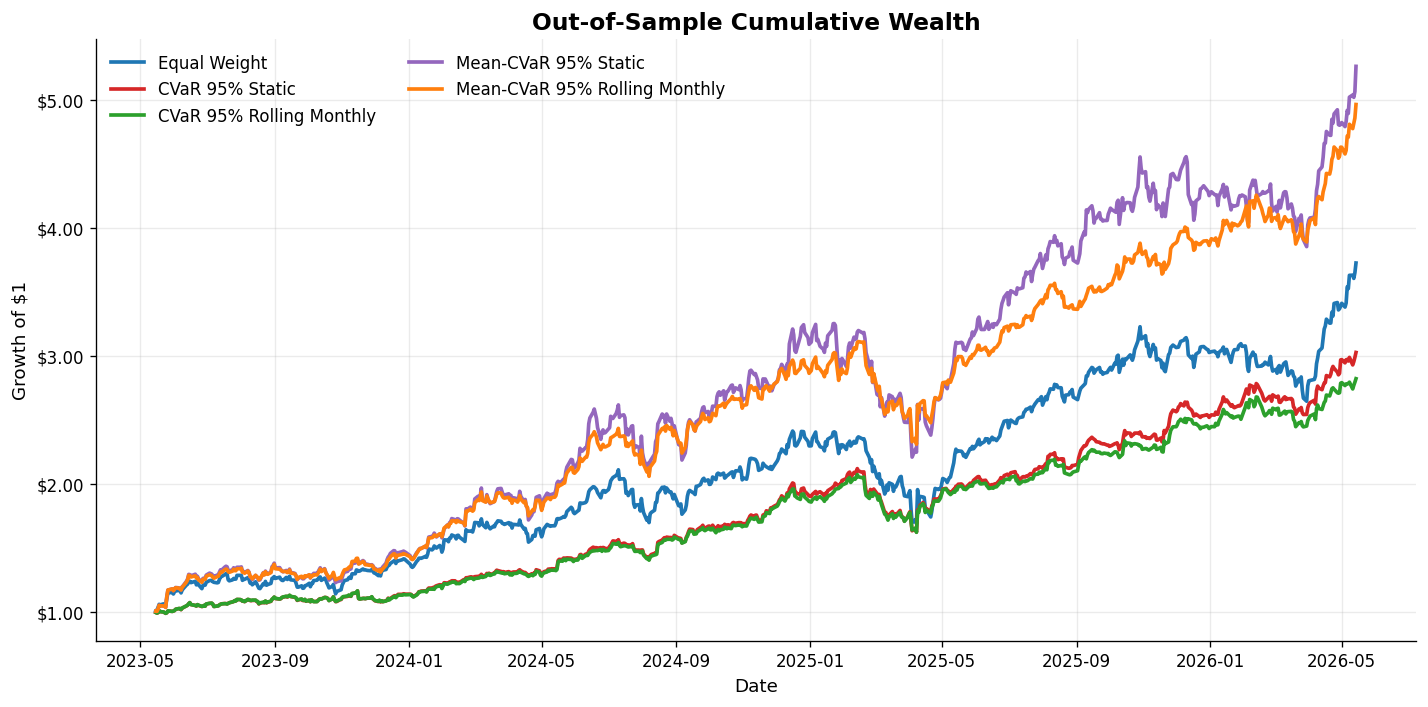

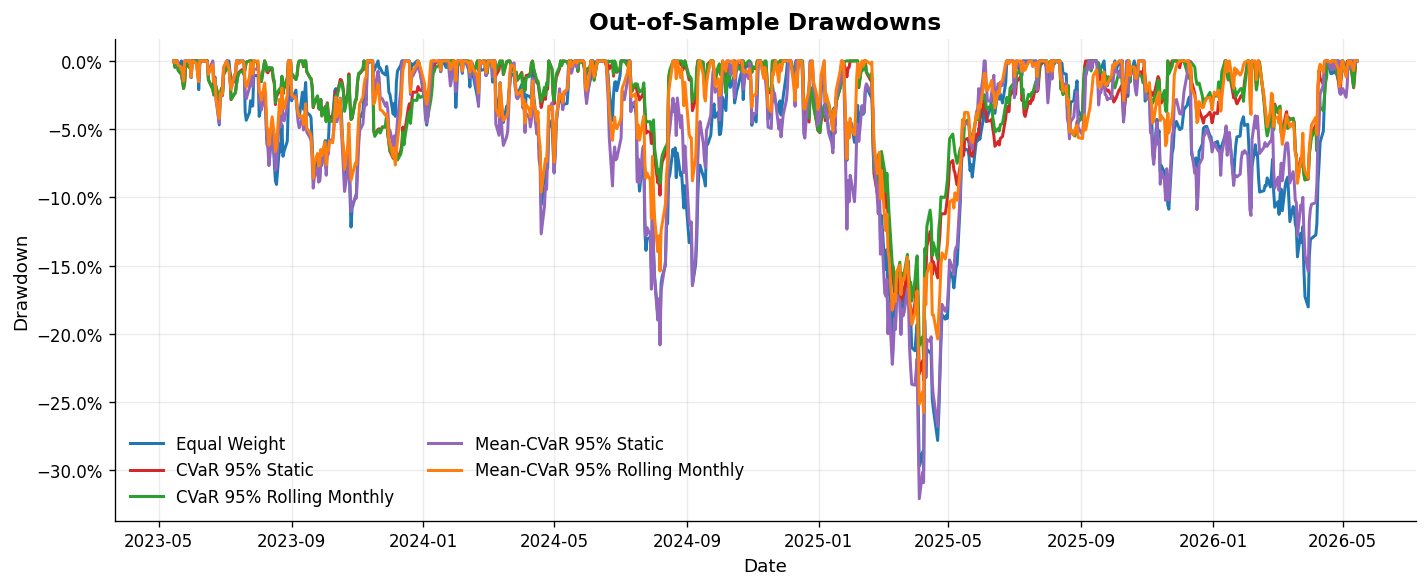

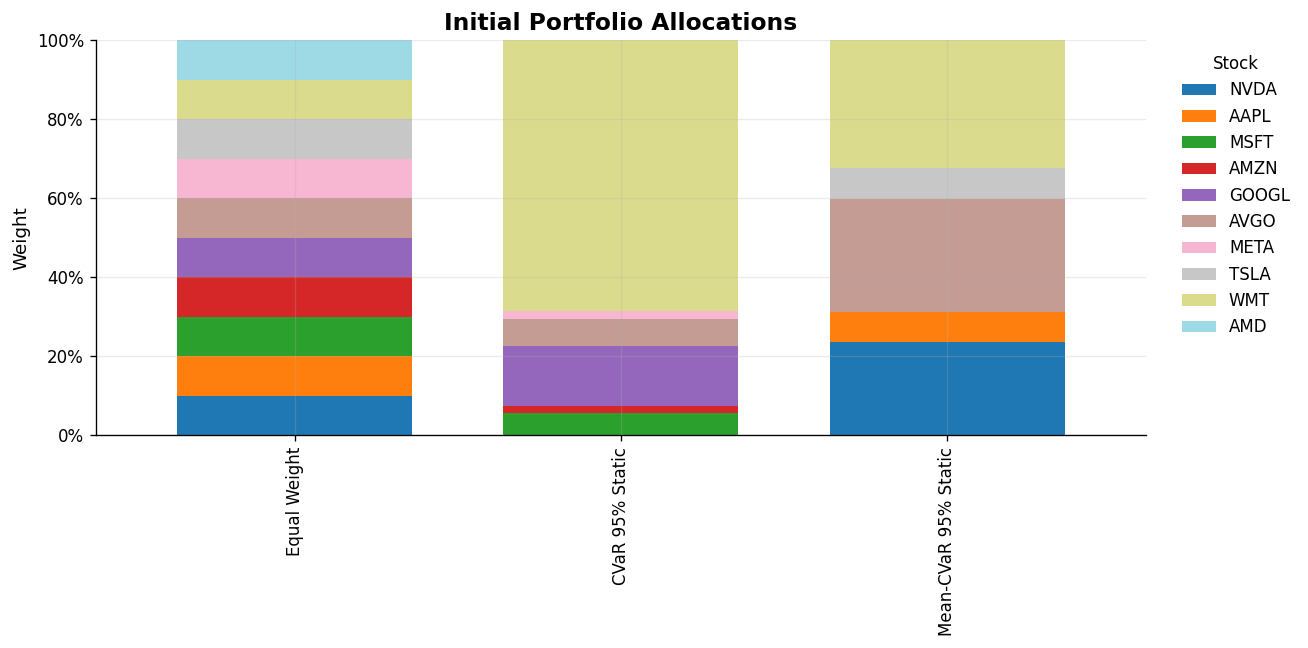

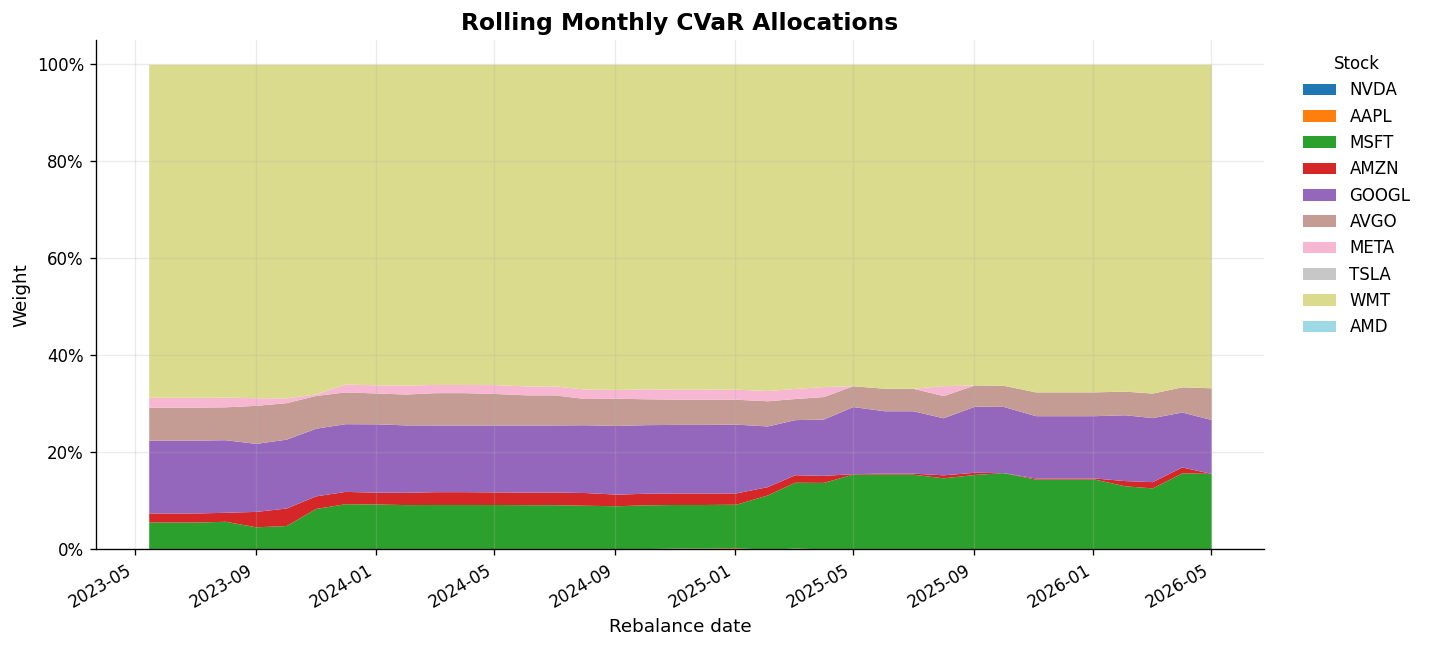

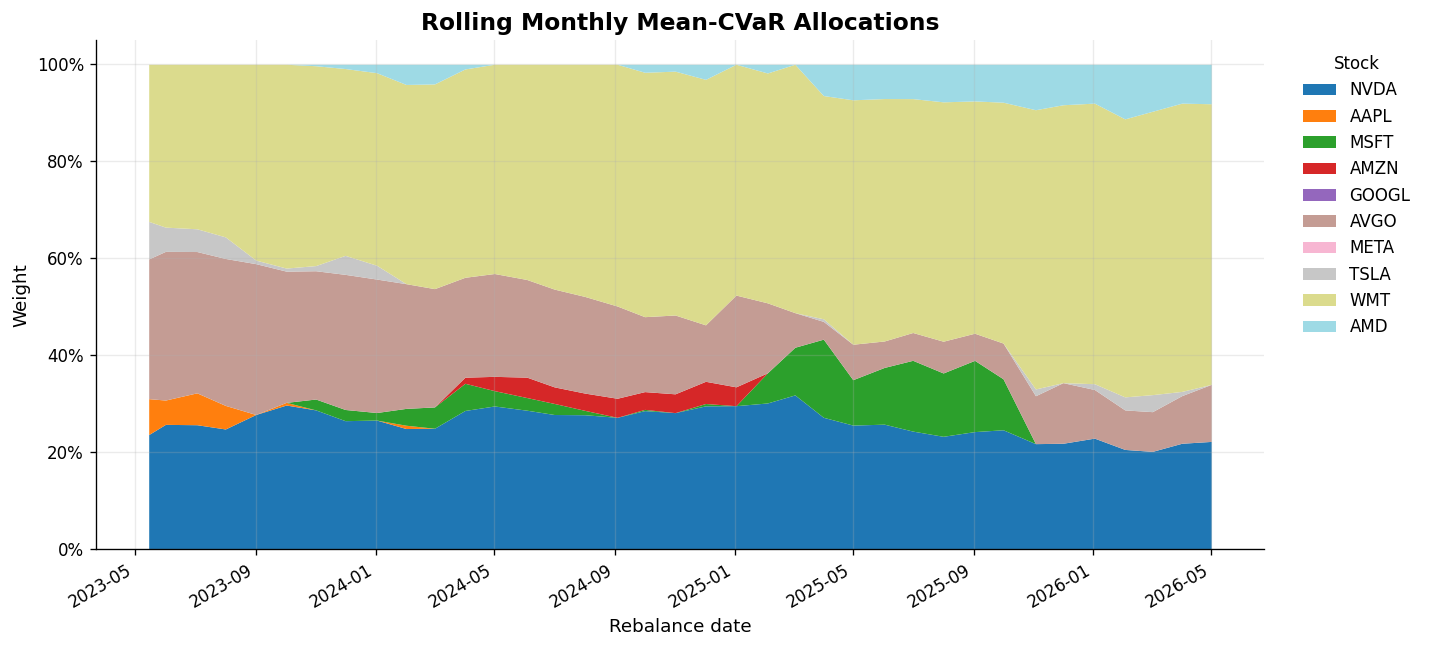

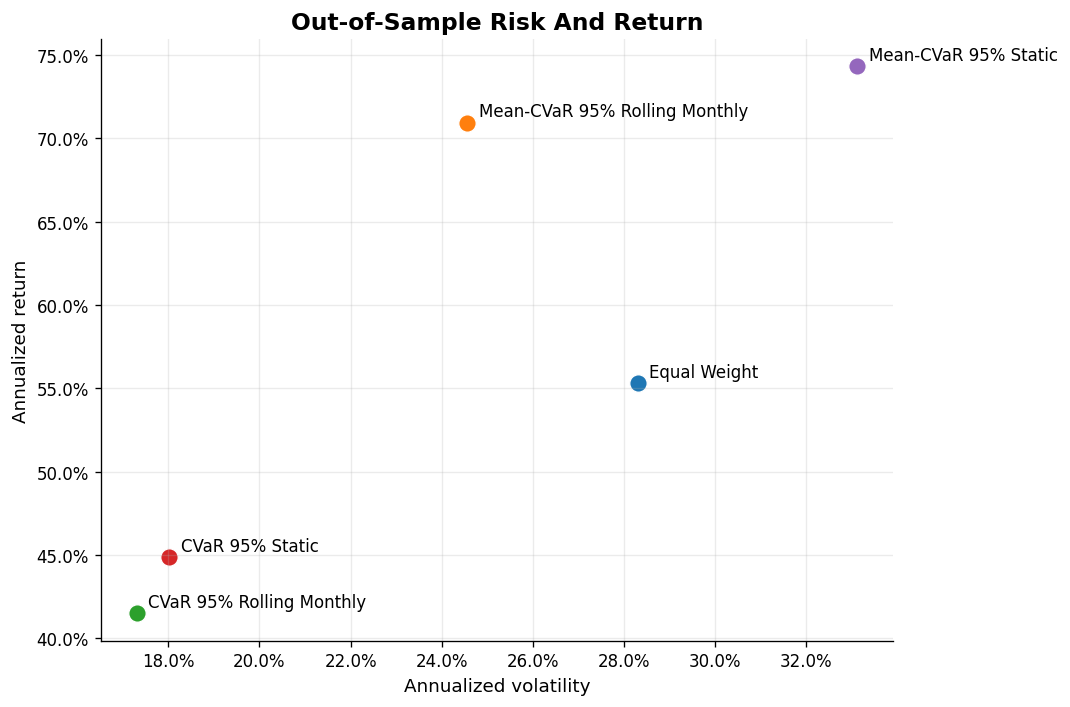

In [18]:
COLORS = {
    "Equal Weight": "#1f77b4",
    "CVaR 95% Static": "#d62728",
    "CVaR 95% Rolling Monthly": "#2ca02c",
    "Mean-CVaR 95% Static": "#9467bd",
    "Mean-CVaR 95% Rolling Monthly": "#ff7f0e",
}

if EXPORT_FIGURES:
    FIGURE_DIR.mkdir(exist_ok=True)


def save_figure(fig, filename):
    if EXPORT_FIGURES:
        fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")


def plot_cumulative_wealth(strategy_returns):
    wealth = (1.0 + strategy_returns).cumprod()
    fig, ax = plt.subplots(figsize=(12, 6))
    for column in strategy_returns.columns:
        ax.plot(wealth.index, wealth[column], label=column, color=COLORS[column], linewidth=2.2)
    ax.set_title("Out-of-Sample Cumulative Wealth")
    ax.set_ylabel("Growth of $1")
    ax.set_xlabel("Date")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.2f}"))
    ax.legend(ncol=2, loc="best")
    fig.tight_layout()
    save_figure(fig, "cumulative_wealth.png")
    return fig, ax


def plot_drawdowns(strategy_returns):
    wealth = (1.0 + strategy_returns).cumprod()
    drawdowns = wealth / wealth.cummax() - 1.0
    fig, ax = plt.subplots(figsize=(12, 5))
    for column in strategy_returns.columns:
        ax.plot(drawdowns.index, drawdowns[column], label=column, color=COLORS[column], linewidth=1.8)
    ax.set_title("Out-of-Sample Drawdowns")
    ax.set_ylabel("Drawdown")
    ax.set_xlabel("Date")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(ncol=2, loc="lower left")
    fig.tight_layout()
    save_figure(fig, "drawdowns.png")
    return fig, ax


def plot_static_weights(static_weights):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    static_weights.T.plot(kind="bar", stacked=True, ax=ax, width=0.72, colormap="tab20")
    ax.set_title("Initial Portfolio Allocations")
    ax.set_ylabel("Weight")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(title="Stock", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    save_figure(fig, "static_allocations.png")
    return fig, ax


def plot_rolling_weights(weights, title, filename):
    fig, ax = plt.subplots(figsize=(12, 5.5))
    weights.plot(kind="area", stacked=True, ax=ax, colormap="tab20", linewidth=0)
    ax.set_title(title)
    ax.set_ylabel("Weight")
    ax.set_xlabel("Rebalance date")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(title="Stock", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    save_figure(fig, filename)
    return fig, ax


def plot_risk_return(metrics):
    fig, ax = plt.subplots(figsize=(9, 6))
    for strategy, row in metrics.iterrows():
        ax.scatter(
            row["annual_volatility"],
            row["annual_return"],
            s=110,
            color=COLORS[strategy],
            label=strategy,
            edgecolor="white",
            linewidth=0.8,
        )
        ax.annotate(strategy, (row["annual_volatility"], row["annual_return"]), xytext=(7, 4), textcoords="offset points")
    ax.set_title("Out-of-Sample Risk And Return")
    ax.set_xlabel("Annualized volatility")
    ax.set_ylabel("Annualized return")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    fig.tight_layout()
    save_figure(fig, "risk_return_scatter.png")
    return fig, ax


plot_cumulative_wealth(strategy_returns)
plot_drawdowns(strategy_returns)
plot_static_weights(static_weights)
plot_rolling_weights(rolling_cvar_weights, "Rolling Monthly CVaR Allocations", "rolling_cvar_allocations.png")
plot_rolling_weights(rolling_mean_cvar_weights, "Rolling Monthly Mean-CVaR Allocations", "rolling_mean_cvar_allocations.png")
plot_risk_return(metrics)
plt.show()

## Optional: Efficient Frontier

The efficient frontier shows the best attainable CVaR risk for different target expected returns. In a mean-CVaR project, this is useful because it visually explains the trade-off: requiring higher expected return usually forces the optimizer to accept more tail risk.

Sharpe ratio is also reported above. It is the annualized excess return divided by annualized volatility. It is not a CVaR measure, but it is familiar to audiences and useful for comparing against standard finance benchmarks.

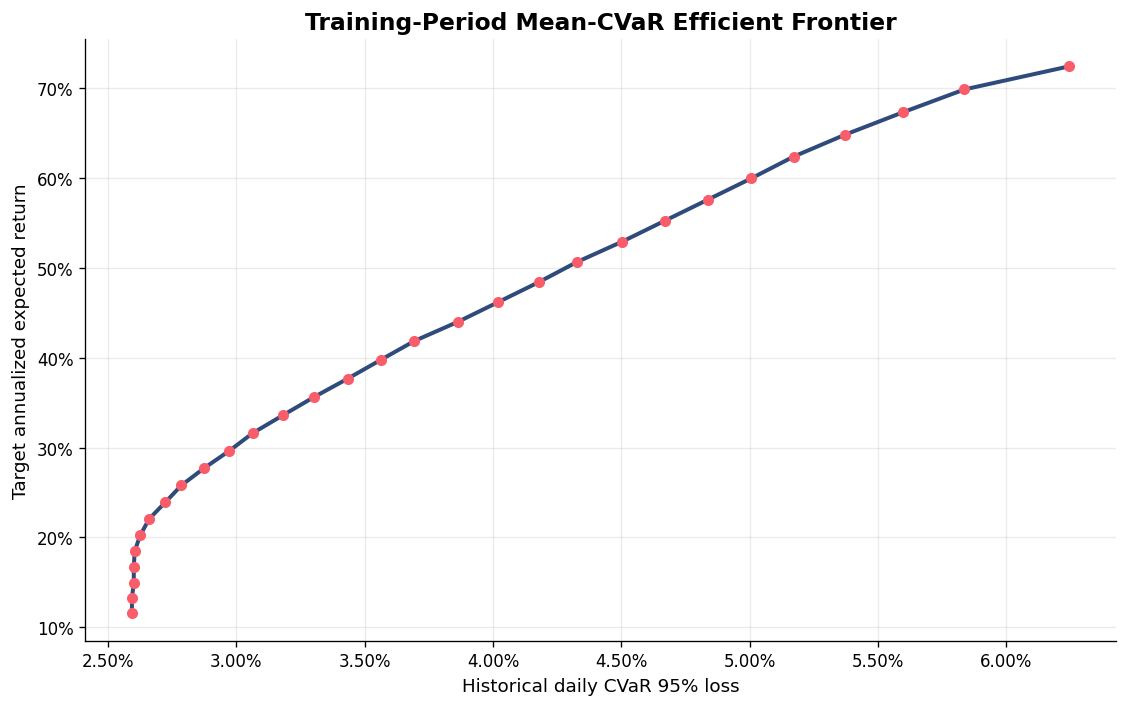

,target_annual_return,daily_cvar_loss
0,11.57%,2.59%
1,13.25%,2.59%
2,14.97%,2.60%
3,16.71%,2.60%
4,18.47%,2.60%
5,20.27%,2.63%
6,22.08%,2.66%
7,23.93%,2.72%
8,25.81%,2.79%
9,27.71%,2.87%


In [19]:
def build_mean_cvar_frontier(train_returns, points=25, alpha=0.95, weight_bounds=(0.0, 1.0)):
    mu_daily = train_returns.mean()
    target_grid = np.linspace(mu_daily.min(), mu_daily.max(), points)
    rows = []

    for target in target_grid:
        try:
            weights, info = solve_cvar_lp(
                train_returns,
                alpha=alpha,
                target_daily_return=float(target),
                weight_bounds=weight_bounds,
            )
        except RuntimeError:
            continue

        portfolio_train_returns = train_returns @ weights
        var_loss, cvar_loss = historical_var_cvar(portfolio_train_returns, alpha)
        rows.append({
            "target_daily_return": float(target),
            "target_annual_return": float((1.0 + target) ** TRADING_DAYS - 1.0),
            "realized_train_annual_return": float((1.0 + portfolio_train_returns.mean()) ** TRADING_DAYS - 1.0),
            "daily_cvar_loss": cvar_loss,
            "objective_cvar_loss": info["objective_cvar_loss"],
            **{f"w_{ticker}": weights[ticker] for ticker in train_returns.columns},
        })

    return pd.DataFrame(rows)


frontier = build_mean_cvar_frontier(
    train_returns,
    points=30,
    alpha=CONFIDENCE_LEVEL,
    weight_bounds=weight_bounds,
)

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.plot(frontier["daily_cvar_loss"], frontier["target_annual_return"], color="#2f4b7c", linewidth=2.4)
ax.scatter(frontier["daily_cvar_loss"], frontier["target_annual_return"], color="#f95d6a", s=32, zorder=3)
ax.set_title("Training-Period Mean-CVaR Efficient Frontier")
ax.set_xlabel(f"Historical daily CVaR {int(CONFIDENCE_LEVEL * 100)}% loss")
ax.set_ylabel("Target annualized expected return")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
fig.tight_layout()
save_figure(fig, "mean_cvar_frontier.png")
plt.show()

display(frontier[["target_annual_return", "daily_cvar_loss"]].style.format("{:.2%}"))

## Report Workflow

Note: This section is to summarize the previous code but with better flow and understanding, used for Methodology parts of reports and for ease of grading.

In [32]:
# ── CELL: Show raw daily returns (first & last 5 rows) ──────────────────
print("=== Daily Return Matrix  (T × n) ===")
print(f"Shape: {returns.shape}  →  {returns.shape[0]} scenarios, {returns.shape[1]} assets\n")
display(
    returns.head(5).style
    .format("{:.4%}")
    .background_gradient(cmap="RdYlGn", axis=None)
    .set_caption("First 5 rows of R (green = gain, red = loss)")
)
display(
    returns.tail(5).style
    .format("{:.4%}")
    .background_gradient(cmap="RdYlGn", axis=None)
    .set_caption("Last 5 rows of R")
)

=== Daily Return Matrix  (T × n) ===
Shape: (3362, 10)  →  3362 scenarios, 10 assets



Ticker,NVDA,AAPL,MSFT,AMZN,GOOGL,AVGO,META,TSLA,WMT,AMD
Date,,,,,,,,,,
2013-01-03 00:00:00,0.0786%,-1.2622%,-1.3396%,0.4547%,0.0581%,0.5224%,-0.8214%,-1.6685%,-0.6355%,-1.5810%
2013-01-04 00:00:00,3.2993%,-2.7854%,-1.8716%,0.2592%,1.9760%,-0.6420%,3.5650%,-1.0642%,0.3779%,4.0161%
2013-01-07 00:00:00,-2.8897%,-0.5883%,-0.1870%,3.5925%,-0.4363%,-0.5538%,2.2949%,-0.1744%,-0.9557%,3.0888%
2013-01-08 00:00:00,-2.1926%,0.2691%,-0.5246%,-0.7748%,-0.1973%,-0.6808%,-1.2237%,-1.9220%,0.2778%,0.0000%
2013-01-09 00:00:00,-2.2418%,-1.5629%,0.5650%,-0.0113%,0.6573%,2.2118%,5.2650%,-0.1187%,-0.0292%,-1.4981%


Ticker,NVDA,AAPL,MSFT,AMZN,GOOGL,AVGO,META,TSLA,WMT,AMD
Date,,,,,,,,,,
2026-05-11 00:00:00,1.9703%,-0.1263%,-0.5926%,-1.3532%,-3.0339%,-0.3651%,-1.7666%,3.8870%,-2.1774%,0.7909%
2026-05-12 00:00:00,0.6106%,0.7243%,-1.1850%,-1.1785%,-0.3319%,-2.1310%,0.6913%,-2.5955%,2.1632%,-2.2886%
2026-05-13 00:00:00,2.2873%,1.3806%,-0.6278%,1.6214%,3.9422%,-0.5986%,2.2604%,2.7270%,0.8592%,-0.6224%
2026-05-14 00:00:00,4.3883%,-0.2208%,1.0414%,-1.0773%,-0.3850%,5.5184%,0.2919%,-0.4424%,0.7530%,0.9428%
2026-05-15 00:00:00,-4.4201%,0.6774%,3.0506%,-1.1526%,-1.0696%,-3.3198%,-0.6791%,-4.7507%,-0.7625%,-5.6927%


In [34]:
# ── CELL: LP variable breakdown — show exactly what goes into the solver ─
alpha = CONFIDENCE_LEVEL
T, n = train_returns.shape

print("=== LP Decision Vector  x = [w, γ, z₁…z_T] ===")
print(f"  Portfolio weights  w  : {n}  variables   (indices 0 … {n-1})")
print(f"  VaR threshold      γ  : 1   variable    (index  {n})")
print(f"  Excess losses      z  : {T}  variables   (indices {n+1} … {n+T})")
print(f"  ─────────────────────────────────────")
print(f"  Total variables      : {n + 1 + T}")
print(f"\nObjective coefficients c:")
print(f"  c[w]  = 0       (weights don't appear in objective directly)")
print(f"  c[γ]  = 1")
print(f"  c[z]  = 1 / ((1-α)·T) = {1/((1-alpha)*T):.6f}  (same for every z_t)")
print(f"\nNumber of inequality constraints (one per scenario): {T}")
print(f"  Form:  -r_t @ w - γ - z_t  ≤  0   for t = 1…{T}")

=== LP Decision Vector  x = [w, γ, z₁…z_T] ===
  Portfolio weights  w  : 10  variables   (indices 0 … 9)
  VaR threshold      γ  : 1   variable    (index  10)
  Excess losses      z  : 2517  variables   (indices 11 … 2527)
  ─────────────────────────────────────
  Total variables      : 2528

Objective coefficients c:
  c[w]  = 0       (weights don't appear in objective directly)
  c[γ]  = 1
  c[z]  = 1 / ((1-α)·T) = 0.007946  (same for every z_t)

Number of inequality constraints (one per scenario): 2517
  Form:  -r_t @ w - γ - z_t  ≤  0   for t = 1…2517


In [35]:
# ── CELL: Show what γ* and z* look like after solving ────────────────────
weights, info = solve_cvar_lp(train_returns, alpha=CONFIDENCE_LEVEL)

scenario_losses = -train_returns.to_numpy() @ weights.to_numpy()   # y_t = -r_t^T w*
gamma_star      = np.quantile(scenario_losses, CONFIDENCE_LEVEL)    # VaR = γ*
z_star          = np.maximum(scenario_losses - gamma_star, 0)       # z_t* = max(y_t - γ*, 0)
cvar_check      = gamma_star + z_star.mean() / (1 - CONFIDENCE_LEVEL)

tail_mask = scenario_losses >= gamma_star

print(f"=== LP Solution Decomposition ===")
print(f"  γ*  (VaR at {int(CONFIDENCE_LEVEL*100)}%)      = {gamma_star:.4%}  daily loss threshold")
print(f"  CVaR (objective value)  = {cvar_check:.4%}  average loss in worst {int((1-CONFIDENCE_LEVEL)*100)}% of days")
print(f"  Tail days (z_t > 0)    : {tail_mask.sum()} of {len(scenario_losses)} scenarios ({tail_mask.mean():.1%})")
print(f"  Mean z_t across tail   : {z_star[z_star>0].mean():.4%}")

# Show the worst 8 scenarios
worst_idx = np.argsort(scenario_losses)[::-1][:8]
worst_df = pd.DataFrame({
    "Date": train_returns.index[worst_idx],
    "Portfolio loss  yₜ": scenario_losses[worst_idx],
    "Excess above γ*  zₜ": z_star[worst_idx],
    "In CVaR tail?": tail_mask[worst_idx],
}).set_index("Date")
display(
    worst_df.style
    .format({"Portfolio loss  yₜ": "{:.3%}", "Excess above γ*  zₜ": "{:.3%}"})
    .set_caption("8 worst in-sample scenarios — these define CVaR")
)

=== LP Solution Decomposition ===
  γ*  (VaR at 95%)      = 1.6875%  daily loss threshold
  CVaR (objective value)  = 2.6014%  average loss in worst 5% of days
  Tail days (z_t > 0)    : 127 of 2517 scenarios (5.0%)
  Mean z_t across tail   : 0.9201%


,Portfolio loss yₜ,Excess above γ* zₜ,In CVaR tail?
Date,,,
2020-03-12 00:00:00,9.082%,7.394%,True
2020-03-16 00:00:00,8.738%,7.051%,True
2022-05-17 00:00:00,7.026%,5.339%,True
2018-02-20 00:00:00,6.805%,5.117%,True
2015-10-14 00:00:00,6.750%,5.063%,True
2022-05-18 00:00:00,6.166%,4.479%,True
2022-07-26 00:00:00,5.935%,4.247%,True
2020-03-11 00:00:00,4.682%,2.995%,True


In [36]:
# ── CELL: Daily portfolio return table for every strategy ────────────────
print("=== Daily Strategy Returns (out-of-sample) ===")
display(
    strategy_returns.head(10).style
    .format("{:.4%}")
    .background_gradient(cmap="RdYlGn", axis=None)
    .bar(subset=strategy_returns.columns, align="zero", color=["#d65f5f","#5fba7d"])
    .set_caption("First 10 out-of-sample trading days")
)
print(f"\nShape: {strategy_returns.shape}  →  {strategy_returns.shape[0]} test days × {strategy_returns.shape[1]} strategies")

=== Daily Strategy Returns (out-of-sample) ===


,Equal Weight,CVaR 95% Static,CVaR 95% Rolling Monthly,Mean-CVaR 95% Static,Mean-CVaR 95% Rolling Monthly
Date,,,,,
2023-05-15 00:00:00,0.6063%,-0.4993%,-0.4993%,0.5587%,0.5587%
2023-05-16 00:00:00,0.9402%,-0.4644%,-0.4644%,-0.1435%,-0.1435%
2023-05-17 00:00:00,1.8171%,0.3553%,0.3553%,1.8420%,1.8420%
2023-05-18 00:00:00,2.3970%,1.5192%,1.5192%,2.7741%,2.7741%
2023-05-19 00:00:00,-0.4124%,-0.7014%,-0.7014%,-0.3075%,-0.3075%
2023-05-22 00:00:00,0.7619%,-0.2864%,-0.2864%,-0.1612%,-0.1612%
2023-05-23 00:00:00,-0.8094%,-0.4790%,-0.4790%,-0.3365%,-0.3365%
2023-05-24 00:00:00,-0.2547%,-0.5698%,-0.5698%,-0.6786%,-0.6786%
2023-05-25 00:00:00,5.0802%,0.4276%,0.4276%,7.9945%,7.9945%



Shape: (753, 5)  →  753 test days × 5 strategies
